In [1]:
#modelo com ML nao supervisionado para tratamento de dados e modelo supervisionado para previsao de gostos usando dados sem genomics

#bibliotecas basicas
from importlib.resources import path

import pandas as pd
import numpy as np

import joblib

# visualização de dados
import matplotlib.pyplot as plt
import plotly.express as px # biblioteca para graficos interativos que interagem bem com pandas

# Machine learning features
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA #para não supervisionado
from sklearn.cluster import KMeans #para não supervisionado
from sklearn.metrics import silhouette_score #para não supervisionado
from sklearn.manifold import TSNE #para não supervisionado
from sklearn.model_selection import train_test_split 
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


In [2]:
# configurações de dados
from pathlib import Path

DATA_PATH = Path(r"D:\Kaggle chalenges\movielens\Data\No_Genomics")

print('lendo os arquivos csv do dataset MovieLens 33M')
#leitura dos arquivos csv

movies = pd.read_csv(DATA_PATH / "movies.csv")

print('lendo movies.csv')

ratings = pd.read_csv(DATA_PATH / "ratings.csv")

print('lendo ratings.csv')





lendo os arquivos csv do dataset MovieLens 33M
lendo movies.csv
lendo ratings.csv


In [3]:
# data verificaion  
print("movies.csv info:")
print(movies.head())

print("ratings.csv info:")
print(ratings.head())



movies.csv info:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  
ratings.csv info:
   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858


In [4]:
from sklearn.preprocessing import MultiLabelBinarizer

# separa os gêneros que estão juntos por "|"
movies_genres = movies[["movieId", "genres"]].copy()

movies_genres["genres"] = movies_genres["genres"].str.split("|")


# cria as colunas binárias
mlb = MultiLabelBinarizer()

genres_encoded = mlb.fit_transform(movies_genres["genres"])


# cria o dataframe final
genres_df = pd.DataFrame(
    genres_encoded,
    columns=mlb.classes_
)


# adiciona movieId novamente
genres_df.insert(
    0,
    "movieId",
    movies_genres["movieId"]
)


print(genres_df.head())
print(genres_df.shape)

   movieId  (no genres listed)  Action  Adventure  Animation  Children  \
0        1                   0       0          1          1         1   
1        2                   0       0          1          0         1   
2        3                   0       0          0          0         0   
3        4                   0       0          0          0         0   
4        5                   0       0          0          0         0   

   Comedy  Crime  Documentary  Drama  ...  Film-Noir  Horror  IMAX  Musical  \
0       1      0            0      0  ...          0       0     0        0   
1       0      0            0      0  ...          0       0     0        0   
2       1      0            0      0  ...          0       0     0        0   
3       1      0            0      1  ...          0       0     0        0   
4       1      0            0      0  ...          0       0     0        0   

   Mystery  Romance  Sci-Fi  Thriller  War  Western  
0        0        0       

In [5]:
#inicio do processamento

#extrair o ano do filme do título e criar uma nova coluna 'year' no dataframe movies
movies["year"] = (
    movies["title"]
    .str.extract(r"\((\d{4})\)")
)
#converter strings para números, tratando erros de conversão
movies["year"] = pd.to_numeric(
    movies["year"],
    errors="coerce"
)

# impromir cabecalho
print(movies.head())

#verificar quantos valores ausentes existem na coluna 'year'
movies["year"].isna().sum()

movies[movies["year"].isna()].head(10)

#limpar filmes sem ano de lançamento

movies = movies.dropna(subset=["year"])
movies = movies.dropna(subset=["genres"])
movies = movies[
    movies["genres"] != "(no genres listed)"
]

print(f"Filmes restantes: {movies.shape[0]}")

movies["year"].describe()

   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres    year  
0  Adventure|Animation|Children|Comedy|Fantasy  1995.0  
1                   Adventure|Children|Fantasy  1995.0  
2                               Comedy|Romance  1995.0  
3                         Comedy|Drama|Romance  1995.0  
4                                       Comedy  1995.0  
Filmes restantes: 80263


count    80263.000000
mean      1995.839876
std         25.697990
min       1874.000000
25%       1982.000000
50%       2006.000000
75%       2015.000000
max       2023.000000
Name: year, dtype: float64

In [6]:
#Split the data into training and testing sets

CUT_YEAR = 2015

data_train = movies[
    movies["year"] < CUT_YEAR
].copy()

data_valid = movies[
    movies["year"] >= CUT_YEAR
].copy()

print(data_valid.head())


       movieId                                      title  \
21706   111781  Mission: Impossible - Rogue Nation (2015)   
22082   113345                   Jupiter Ascending (2015)   
22608   115713                          Ex Machina (2015)   
23234   117466             In the Heart of the Sea (2015)   
23265   117529                      Jurassic World (2015)   

                                       genres    year  
21706               Action|Adventure|Thriller  2015.0  
22082                 Action|Adventure|Sci-Fi  2015.0  
22608                   Drama|Sci-Fi|Thriller  2015.0  
23234                  Action|Adventure|Drama  2015.0  
23265  Action|Adventure|Drama|Sci-Fi|Thriller  2015.0  


In [7]:
# iniciar ML não supervisionado para clusterização de filmes com base em seus genomas

#selecionar serie de genomas para filmes do conjunto de treinamento
genres_train = movies_genres[
    movies_genres["movieId"].isin(
        data_train["movieId"]
    )
].copy()

X_train_genres = genres_train.drop(
    columns="movieId")

print(X_train_genres.head())


                                              genres
0  [Adventure, Animation, Children, Comedy, Fantasy]
1                     [Adventure, Children, Fantasy]
2                                  [Comedy, Romance]
3                           [Comedy, Drama, Romance]
4                                           [Comedy]


In [8]:
#gera matrizminaria de generos

from sklearn.preprocessing import MultiLabelBinarizer

mlb = MultiLabelBinarizer()

genre_matrix = mlb.fit_transform(
    genres_train["genres"]
)

X_genres = pd.DataFrame(
    genre_matrix,
    columns=mlb.classes_,
    index=genres_train["movieId"]
)

print(X_genres.head())

         Action  Adventure  Animation  Children  Comedy  Crime  Documentary  \
movieId                                                                       
1             0          1          1         1       1      0            0   
2             0          1          0         1       0      0            0   
3             0          0          0         0       1      0            0   
4             0          0          0         0       1      0            0   
5             0          0          0         0       1      0            0   

         Drama  Fantasy  Film-Noir  Horror  IMAX  Musical  Mystery  Romance  \
movieId                                                                       
1            0        1          0       0     0        0        0        0   
2            0        1          0       0     0        0        0        0   
3            0        0          0       0     0        0        0        1   
4            1        0          0       0     0   

In [9]:
#pca - 

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans


#PCA antes do clustering
pca_cluster = PCA(
   n_components=10,
   random_state=42
)

X_genres_pca = pca_cluster.fit_transform(
   X_genres
)


print(
    pca_cluster.explained_variance_ratio_.sum()
)

0.8363494400407641


In [10]:

from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score


N_CLUSTERS = 30

kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init="auto",
    verbose=1
)

clusters = kmeans.fit_predict(X_genres_pca)

# ===========================
# Métricas
# ===========================

inertia = kmeans.inertia_

silhouette = silhouette_score(
    X_genres_pca,
    clusters
)

davies = davies_bouldin_score(
    X_genres_pca,
    clusters
)

calinski = calinski_harabasz_score(
    X_genres_pca,
    clusters
)

print(f"Número de clusters: {N_CLUSTERS}")
print(f"Inertia (WCSS): {inertia:.2f}")
print(f"Silhouette Score: {silhouette:.4f}")
print(f"Davies-Bouldin Index: {davies:.4f}")
print(f"Calinski-Harabasz Score: {calinski:.2f}")

# ===========================
# Criar tabela dos clusters
# ===========================

movie_clusters = pd.DataFrame({
    "movieId": genres_train["movieId"].values,
    "cluster": clusters
})

movie_clusters = movie_clusters.merge(
    movies,
    on="movieId"
)

# ===========================
# Quantidade de filmes por cluster
# ===========================

print("\nQuantidade de filmes por cluster:")

print(
    movie_clusters["cluster"]
    .value_counts()
    .sort_index()
)

# ===========================
# Exemplo de um cluster
# ===========================

movie_clusters[
    movie_clusters["cluster"] == 3
].head(20)


Initialization complete
Iteration 0, inertia 12782.57407242056.
Iteration 1, inertia 10975.893554646747.
Iteration 2, inertia 10884.244373659787.
Iteration 3, inertia 10870.412559535189.
Iteration 4, inertia 10870.086023401007.
Iteration 5, inertia 10869.894485582026.
Iteration 6, inertia 10869.829916482093.
Converged at iteration 6: strict convergence.
Número de clusters: 30
Inertia (WCSS): 10869.83
Silhouette Score: 0.6505
Davies-Bouldin Index: 0.9460
Calinski-Harabasz Score: 11161.46

Quantidade de filmes por cluster:
cluster
0      2103
1     11464
2      2351
3      5025
4      7037
5      1064
6       786
7      1247
8       694
9      1902
10     2695
11     3235
12     1252
13     1591
14     1119
15     2958
16     1389
17      641
18      929
19      741
20      326
21      598
22      758
23      898
24     1295
25      463
26     1271
27      656
28      974
29      375
Name: count, dtype: int64


,movieId,cluster,title,genres,year
36,37,3,Across the Sea of Time (1995),Documentary|IMAX,1995.0
76,77,3,Nico Icon (1995),Documentary,1995.0
97,99,3,Heidi Fleiss: Hollywood Madam (1995),Documentary,1995.0
106,108,3,Catwalk (1996),Documentary,1996.0
114,116,3,Anne Frank Remembered (1995),Documentary,1995.0
126,128,3,Jupiter's Wife (1994),Documentary,1994.0
132,134,3,Sonic Outlaws (1995),Documentary,1995.0
134,136,3,From the Journals of Jean Seberg (1995),Documentary,1995.0
135,137,3,Man of the Year (1995),Documentary,1995.0
160,162,3,Crumb (1994),Documentary,1994.0


In [11]:
# Salvar KMeans

joblib.dump(
    kmeans,
    "kmeans_movies.pkl"
)

print("KMeans salvo.")

KMeans salvo.


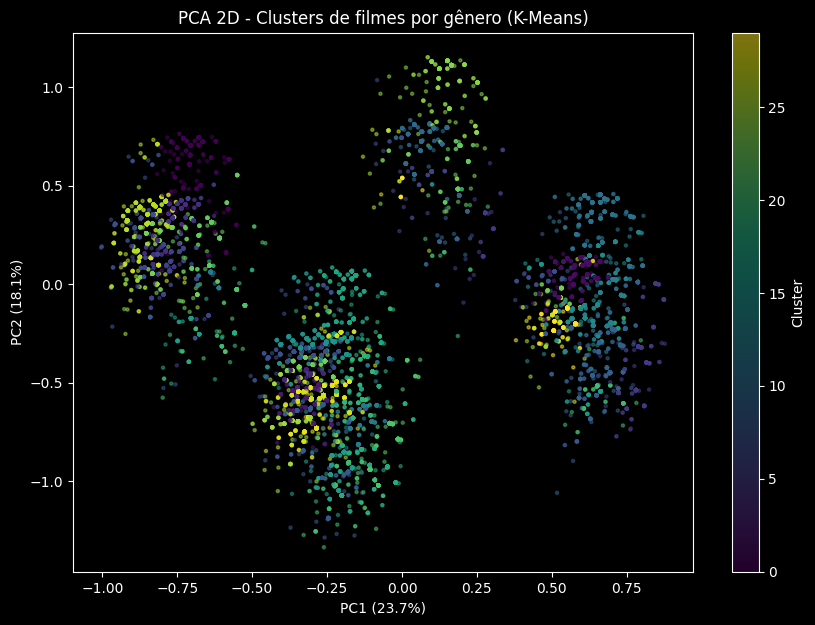

In [12]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd


# ===========================
# PCA 2D para visualização
# ===========================

pca_vis = PCA(
    n_components=2
)

X_pca_vis = pca_vis.fit_transform(
    X_genres_pca
)


# Criar dataframe para plot
pca_df = pd.DataFrame(
    X_pca_vis,
    columns=["PC1", "PC2"]
)

pca_df["cluster"] = clusters


# ===========================
# Gráfico PCA com clusters
# ===========================

plt.figure(figsize=(10, 7))

plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["cluster"],
    s=5,
    alpha=0.5
)

plt.xlabel(
    f"PC1 ({pca_vis.explained_variance_ratio_[0]*100:.1f}%)"
)

plt.ylabel(
    f"PC2 ({pca_vis.explained_variance_ratio_[1]*100:.1f}%)"
)

plt.title(
    "PCA 2D - Clusters de filmes por gênero (K-Means)"
)

plt.colorbar(
    label="Cluster"
)

plt.show()

In [13]:
for n in sorted(movie_clusters["cluster"].unique()):
    
    cluster = movie_clusters[
        movie_clusters["cluster"] == n
    ]

    print("\n===================")
    print(f"CLUSTER {n} ({len(cluster)} filmes)")
    print("===================")

    print(
        cluster["genres"]
        .value_counts()
        .head(5)
    )


CLUSTER 0 (2103 filmes)
genres
Comedy|Romance            1566
Comedy|Musical|Romance     131
Comedy|Fantasy|Romance      63
Action|Comedy|Romance       53
Comedy|Crime|Romance        40
Name: count, dtype: int64

CLUSTER 1 (11464 filmes)
genres
Drama              9000
Drama|War           700
Children|Drama      330
Adventure|Drama     222
Drama|Mystery       193
Name: count, dtype: int64

CLUSTER 2 (2351 filmes)
genres
Horror                1587
Horror|Sci-Fi          366
Horror|Mystery         129
Fantasy|Horror          79
Documentary|Horror      25
Name: count, dtype: int64

CLUSTER 3 (5025 filmes)
genres
Documentary              4684
Documentary|War           106
Documentary|Musical        82
Adventure|Documentary      33
Animation|Documentary      33
Name: count, dtype: int64

CLUSTER 4 (7037 filmes)
genres
Comedy                5726
Comedy|Horror          354
Comedy|Fantasy         156
Comedy|Documentary     145
Comedy|Musical         141
Name: count, dtype: int64

CLUSTER 5 (10

In [14]:
# ============================================================
# ATRIBUIR FILMES DA VALIDAÇÃO AOS CLUSTERS DO K-MEANS TREINADO
# ============================================================

# Seleciona apenas os gêneros dos filmes pertencentes ao conjunto de validação
# (mesmos dados de filmes, mas após o corte temporal definido)
genres_valid = movies_genres[
    movies_genres["movieId"].isin(
        data_valid["movieId"]
    )
].copy()


# Aplica o mesmo MultiLabelBinarizer treinado no conjunto de treino
# NÃO usar fit_transform aqui, pois isso criaria novas categorias de gênero
# O transform apenas converte os gêneros usando as classes aprendidas no treino
genre_matrix_valid = mlb.transform(
    genres_valid["genres"]
)


# Cria um DataFrame com a matriz binária de gêneros da validação
# Usamos as mesmas colunas de gênero aprendidas no treinamento
# para garantir que treino e validação tenham exatamente as mesmas features
X_genres_valid = pd.DataFrame(
    genre_matrix_valid,
    columns=mlb.classes_,
    index=genres_valid["movieId"]
)


# Aplica o mesmo PCA treinado no conjunto de treino
# NÃO usar fit_transform, pois o PCA precisa manter os mesmos eixos
# aprendidos durante o treinamento
X_genres_valid_pca = pca_cluster.transform(
    X_genres_valid
)


# Usa o modelo K-Means já treinado para prever o cluster
# de cada filme da validação baseado nos centróides encontrados no treino
valid_clusters = kmeans.predict(
    X_genres_valid_pca
)


# Cria uma tabela relacionando cada filme da validação
# ao cluster ao qual ele foi atribuído
movie_clusters_valid = pd.DataFrame({
    "movieId": genres_valid["movieId"].values,
    "cluster": valid_clusters
})


# Junta o cluster atribuído com as informações dos filmes
# (título, gêneros, ano etc.)
movie_clusters_valid = movie_clusters_valid.merge(
    movies,
    on="movieId"
)


# Visualiza os primeiros filmes e seus respectivos clusters
print(movie_clusters_valid.head())


# Mostra quantos filmes foram atribuídos a cada cluster na validação
print("\nQuantidade de filmes por cluster na validação:")
print(
    movie_clusters_valid["cluster"]
    .value_counts()
    .sort_index()
)

   movieId  cluster                                      title  \
0   111781       20  Mission: Impossible - Rogue Nation (2015)   
1   113345       25                   Jupiter Ascending (2015)   
2   115713        9                          Ex Machina (2015)   
3   117466       14             In the Heart of the Sea (2015)   
4   117529       20                      Jurassic World (2015)   

                                   genres    year  
0               Action|Adventure|Thriller  2015.0  
1                 Action|Adventure|Sci-Fi  2015.0  
2                   Drama|Sci-Fi|Thriller  2015.0  
3                  Action|Adventure|Drama  2015.0  
4  Action|Adventure|Drama|Sci-Fi|Thriller  2015.0  

Quantidade de filmes por cluster na validação:
cluster
0      792
1     4095
2     1122
3     3479
4     2411
5      269
6      276
7      359
8      263
9      881
10    1151
11     812
12     945
13     345
14     252
15     660
16     793
17     516
18     439
19     217
20      54
21  

Inicio do treinamento supervisionado

In [15]:
# ETAPA 1 - Construir o perfil de cada usuário por cluster


# Junta cada avaliação ao cluster do filme
ratings_clusters = ratings.merge(
    movie_clusters[["movieId", "cluster"]],
    on="movieId",
    how="inner"
)

# Número de filmes assistidos por cada usuário
user_total_movies = (
    ratings_clusters
    .groupby("userId")
    .size()
    .rename("user_total_movies")
)

# Número de filmes existentes em cada cluster
cluster_total_movies = (
    movie_clusters
    .groupby("cluster")
    .size()
    .rename("cluster_total_movies")
)

# Estatísticas do usuário em cada cluster
user_cluster_profile = (
    ratings_clusters
    .groupby(["userId", "cluster"])
    .agg(
        movies_seen=("movieId", "count"),
        mean_rating=("rating", "mean"),
        std_rating=("rating", "std")
    )
    .reset_index()
)

# Junta informações auxiliares
user_cluster_profile = (
    user_cluster_profile
    .merge(user_total_movies, on="userId")
    .merge(cluster_total_movies, on="cluster")
)

# Fração das avaliações do usuário que pertencem a esse cluster
user_cluster_profile["cluster_preference"] = (
    user_cluster_profile["movies_seen"]
    / user_cluster_profile["user_total_movies"]
)

# Fração dos filmes daquele cluster que o usuário já assistiu
user_cluster_profile["cluster_coverage"] = (
    user_cluster_profile["movies_seen"]
    / user_cluster_profile["cluster_total_movies"]
)

# Preenche desvio padrão quando o usuário avaliou apenas um filme
user_cluster_profile["std_rating"] = (
    user_cluster_profile["std_rating"]
    .fillna(0)
)

# Visualizar resultado
user_cluster_profile.tail()

,userId,cluster,movies_seen,mean_rating,std_rating,user_total_movies,cluster_total_movies,cluster_preference,cluster_coverage
4228670,200948,25,14,3.464286,1.379301,236,463,0.059322,0.030238
4228671,200948,26,13,3.423077,1.288509,236,1271,0.055085,0.010228
4228672,200948,27,5,4.100000,0.651920,236,656,0.021186,0.007622
4228673,200948,28,1,5.000000,0.000000,236,974,0.004237,0.001027
4228674,200948,29,1,4.500000,0.000000,236,375,0.004237,0.002667


In [16]:
# ETAPA 2 - Normalizar as notas de cada usuário


# Calcula a média e o desvio padrão das notas de cada usuário
user_rating_stats = (
    ratings_clusters
    .groupby("userId")["rating"]
    .agg(["mean", "std"])
    .rename(columns={
        "mean": "user_mean_rating",
        "std": "user_std_rating"
    })
    .reset_index()
)

# Junta essas estatísticas a cada avaliação
ratings_clusters = ratings_clusters.merge(
    user_rating_stats,
    on="userId",
    how="left"
)

# Evita divisão por zero para usuários que possuem desvio padrão igual a zero
ratings_clusters["user_std_rating"] = (
    ratings_clusters["user_std_rating"]
    .replace(0, 1)
)

# Calcula a nota normalizada (Z-score)
ratings_clusters["rating_normalized"] = (
    (
        ratings_clusters["rating"]
        - ratings_clusters["user_mean_rating"]
    )
    / ratings_clusters["user_std_rating"]
)

# Visualizar resultado
ratings_clusters.head()

,userId,movieId,rating,timestamp,cluster,user_mean_rating,user_std_rating,rating_normalized
0,1,17,4.0,944249077,11,3.531915,1.53787,0.304372
1,1,25,1.0,944250228,11,3.531915,1.53787,-1.646377
2,1,29,2.0,943230976,25,3.531915,1.53787,-0.996127
3,1,30,5.0,944249077,13,3.531915,1.53787,0.954622
4,1,32,5.0,943228858,12,3.531915,1.53787,0.954622


In [17]:
# ETAPA 3 - Recalcular o perfil do usuário usando notas normalizadas


# Número de filmes assistidos por cada usuário
user_total_movies = (
    ratings_clusters
    .groupby("userId")
    .size()
    .rename("user_total_movies")
)

# Número de filmes existentes em cada cluster
cluster_total_movies = (
    movie_clusters
    .groupby("cluster")
    .size()
    .rename("cluster_total_movies")
)

# Perfil do usuário em cada cluster
user_cluster_profile = (
    ratings_clusters
    .groupby(["userId", "cluster"])
    .agg(
        movies_seen=("movieId", "count"),

        # Média das notas normalizadas
        mean_rating_norm=("rating_normalized", "mean"),

        # Dispersão das notas normalizadas
        std_rating_norm=("rating_normalized", "std")
    )
    .reset_index()
)

# Junta estatísticas auxiliares
user_cluster_profile = (
    user_cluster_profile
    .merge(user_total_movies, on="userId")
    .merge(cluster_total_movies, on="cluster")
)

# Percentual dos filmes vistos pelo usuário que pertencem ao cluster
user_cluster_profile["cluster_preference"] = (
    user_cluster_profile["movies_seen"]
    / user_cluster_profile["user_total_movies"]
)

# Cobertura do cluster
user_cluster_profile["cluster_coverage"] = (
    user_cluster_profile["movies_seen"]
    / user_cluster_profile["cluster_total_movies"]
)

# Usuários com apenas um filme no cluster
user_cluster_profile["std_rating_norm"] = (
    user_cluster_profile["std_rating_norm"]
    .fillna(0)
)

# Visualizar
user_cluster_profile.head()

,userId,cluster,movies_seen,mean_rating_norm,std_rating_norm,user_total_movies,cluster_total_movies,cluster_preference,cluster_coverage
0,1,0,5,-0.736027,1.088076,141,2103,0.035461,0.002378
1,1,1,40,0.125554,0.998580,141,11464,0.283688,0.003489
2,1,3,1,-0.345878,0.000000,141,5025,0.007092,0.000199
3,1,4,11,0.067918,0.976359,141,7037,0.078014,0.001563
4,1,5,5,-0.345878,1.216506,141,1064,0.035461,0.004699


In [18]:
# ETAPA 4 - Características globais do comportamento do usuário

# Número de clusters diferentes assistidos por cada usuário
user_features = (
    user_cluster_profile
    .groupby("userId")
    .agg(

        # Quantos clusters o usuário já assistiu
        n_clusters=("cluster", "count"),

        # Maior afinidade por um cluster
        max_cluster_preference=("cluster_preference", "max"),

        # Afinidade média
        mean_cluster_preference=("cluster_preference", "mean"),

        # Desvio das afinidades entre clusters
        std_cluster_preference=("cluster_preference", "std"),

        # Média das notas normalizadas
        mean_rating_norm=("mean_rating_norm", "mean")
    )
    .reset_index()
)

# Preenche NaN para usuários com apenas um cluster
user_features["std_cluster_preference"] = (
    user_features["std_cluster_preference"]
    .fillna(0)
)

user_features.head()

,userId,n_clusters,max_cluster_preference,mean_cluster_preference,std_cluster_preference,mean_rating_norm
0,1,22,0.283688,0.045455,0.060760,-0.057152
1,2,17,0.153846,0.058824,0.038142,-0.066495
2,3,26,0.108844,0.038462,0.031081,-0.086635
3,4,15,0.148148,0.066667,0.034856,-0.081656
4,5,19,0.121212,0.052632,0.030036,-0.111633


In [19]:
# SERIE DE VALIDAÇÃO

# ETAPA 1 - Construir o perfil de cada usuário por cluster


# Junta cada avaliação ao cluster do filme
ratings_clusters_valid = ratings.merge(
    movie_clusters_valid[["movieId", "cluster"]],
    on="movieId",
    how="inner"
)

# Número de filmes assistidos por cada usuário
user_total_movies_valid = (
    ratings_clusters_valid
    .groupby("userId")
    .size()
    .rename("user_total_movies")
)

# Número de filmes existentes em cada cluster
cluster_total_movies_valid = (
    movie_clusters_valid
    .groupby("cluster")
    .size()
    .rename("cluster_total_movies")
)

# Estatísticas do usuário em cada cluster
user_cluster_profile_valid = (
    ratings_clusters_valid
    .groupby(["userId", "cluster"])
    .agg(
        movies_seen=("movieId", "count"),
        mean_rating=("rating", "mean"),
        std_rating=("rating", "std")
    )
    .reset_index()
)

# Junta informações auxiliares
user_cluster_profile_valid = (
    user_cluster_profile_valid
    .merge(user_total_movies_valid, on="userId")
    .merge(cluster_total_movies_valid, on="cluster")
)

# Fração das avaliações do usuário que pertencem a esse cluster
user_cluster_profile_valid["cluster_preference"] = (
    user_cluster_profile_valid["movies_seen"]
    / user_cluster_profile_valid["user_total_movies"]
)

# Fração dos filmes daquele cluster que o usuário já assistiu
user_cluster_profile_valid["cluster_coverage"] = (
    user_cluster_profile_valid["movies_seen"]
    / user_cluster_profile_valid["cluster_total_movies"]
)

# Preenche desvio padrão quando o usuário avaliou apenas um filme
user_cluster_profile_valid["std_rating"] = (
    user_cluster_profile_valid["std_rating"]
    .fillna(0)
)

# Visualizar resultado
print(user_cluster_profile_valid.tail())

# ETAPA 2 - Normalizar as notas de cada usuário


# Calcula a média e o desvio padrão das notas de cada usuário
user_rating_stats_valid = (
    ratings_clusters_valid
    .groupby("userId")["rating"]
    .agg(["mean", "std"])
    .rename(columns={
        "mean": "user_mean_rating",
        "std": "user_std_rating"
    })
    .reset_index()
)

# Junta essas estatísticas a cada avaliação
ratings_clusters_valid = ratings_clusters_valid.merge(
    user_rating_stats_valid,
    on="userId",
    how="left"
)

# Evita divisão por zero para usuários que possuem desvio padrão igual a zero
ratings_clusters_valid["user_std_rating"] = (
    ratings_clusters_valid["user_std_rating"]
    .replace(0, 1)
)

# Calcula a nota normalizada (Z-score)
ratings_clusters_valid["rating_normalized"] = (
    (
        ratings_clusters_valid["rating"]
        - ratings_clusters_valid["user_mean_rating"]
    )
    / ratings_clusters_valid["user_std_rating"]
)

# Visualizar resultado
print(ratings_clusters_valid.head())

# ETAPA 3 - Recalcular o perfil do usuário usando notas normalizadas


# Número de filmes assistidos por cada usuário
user_total_movies_valid = (
    ratings_clusters_valid
    .groupby("userId")
    .size()
    .rename("user_total_movies")
)

# Número de filmes existentes em cada cluster
cluster_total_movies_valid = (
    movie_clusters_valid
    .groupby("cluster")
    .size()
    .rename("cluster_total_movies")
)

# Perfil do usuário em cada cluster
user_cluster_profile_valid = (
    ratings_clusters_valid
    .groupby(["userId", "cluster"])
    .agg(
        movies_seen=("movieId", "count"),

        # Média das notas normalizadas
        mean_rating_norm=("rating_normalized", "mean"),

        # Dispersão das notas normalizadas
        std_rating_norm=("rating_normalized", "std")
    )
    .reset_index()
)

# Junta estatísticas auxiliares
user_cluster_profile_valid = (
    user_cluster_profile_valid
    .merge(user_total_movies_valid, on="userId")
    .merge(cluster_total_movies_valid, on="cluster")
)

# Percentual dos filmes vistos pelo usuário que pertencem ao cluster
user_cluster_profile_valid["cluster_preference"] = (
    user_cluster_profile_valid["movies_seen"]
    / user_cluster_profile_valid["user_total_movies"]
)

# Cobertura do cluster
user_cluster_profile_valid["cluster_coverage"] = (
    user_cluster_profile_valid["movies_seen"]
    / user_cluster_profile_valid["cluster_total_movies"]
)

# Usuários com apenas um filme no cluster
user_cluster_profile_valid["std_rating_norm"] = (
    user_cluster_profile_valid["std_rating_norm"]
    .fillna(0)
)

# Visualizar
print(user_cluster_profile_valid.head())

# ETAPA 4 - Características globais do comportamento do usuário

# Número de clusters diferentes assistidos por cada usuário
user_features_valid = (
    user_cluster_profile_valid
    .groupby("userId")
    .agg(

        # Quantos clusters o usuário já assistiu
        n_clusters=("cluster", "count"),

        # Maior afinidade por um cluster
        max_cluster_preference=("cluster_preference", "max"),

        # Afinidade média
        mean_cluster_preference=("cluster_preference", "mean"),

        # Desvio das afinidades entre clusters
        std_cluster_preference=("cluster_preference", "std"),

        # Média das notas normalizadas
        mean_rating_norm=("mean_rating_norm", "mean")
    )
    .reset_index()
)

# Preenche NaN para usuários com apenas um cluster
user_features_valid["std_cluster_preference"] = (
    user_features_valid["std_cluster_preference"]
    .fillna(0)
)

print(user_features_valid.head())

        userId  cluster  movies_seen  mean_rating  std_rating  \
599320  200945       26            1          0.5         0.0   
599321  200947        7            1          5.0         0.0   
599322  200947       20            1          3.5         0.0   
599323  200947       24            1          4.5         0.0   
599324  200947       26            1          3.0         0.0   

        user_total_movies  cluster_total_movies  cluster_preference  \
599320                 14                   388            0.071429   
599321                  4                   359            0.250000   
599322                  4                    54            0.250000   
599323                  4                   303            0.250000   
599324                  4                   388            0.250000   

        cluster_coverage  
599320          0.002577  
599321          0.002786  
599322          0.018519  
599323          0.003300  
599324          0.002577  
   userId  movieId  

In [29]:
# juntar os dois datasets mantendo as mesmas colunas

Merge_cluster_profile = pd.concat(
    [
        user_cluster_profile,
        user_cluster_profile_valid
    ],
    axis=0,
    ignore_index=True
)

# juntar ratings de treino e validação
ratings_all = pd.concat(
    [
        ratings_clusters,
        ratings_clusters_valid
    ],
    axis=0,
    ignore_index=True
)

# adicionar informações do perfil usuário-cluster
ratings_model = ratings_all.merge(
    Merge_cluster_profile,
    on=["userId", "cluster"],
    how="left"
)

user_cluster_profile_all = ratings_model

cols_remove = [
    "user_mean_rating",
    "user_std_rating",
    "rating_normalized",
    "mean_rating_norm",
    "std_rating_norm"
]

user_cluster_profile_all = user_cluster_profile_all.drop(
    columns=cols_remove
)

print(user_cluster_profile_all.head())
print(user_cluster_profile_all.shape)



   userId  movieId  rating  timestamp  cluster  movies_seen  \
0       1       17     4.0  944249077       11           14   
1       1       25     1.0  944250228       11           14   
2       1       29     2.0  943230976       25            7   
3       1       30     5.0  944249077       13            5   
4       1       32     5.0  943228858       12            1   

   user_total_movies  cluster_total_movies  cluster_preference  \
0                141                  3235            0.099291   
1                141                  3235            0.099291   
2                141                   463            0.049645   
3                141                  1591            0.035461   
4                141                  1252            0.007092   

   cluster_coverage  
0          0.004328  
1          0.004328  
2          0.015119  
3          0.003143  
4          0.000799  
(42108340, 10)


Hora de montar ranking dos filmes

In [26]:
movieranking = (
    user_cluster_profile_all
    .groupby(["cluster", "movieId"], as_index=False)["rating"]
    .mean()
    .rename(columns={"rating": "mean_rating"})
    .sort_values(["cluster", "mean_rating"], ascending=[True, False])
)
movieranking.head()

,cluster,movieId,mean_rating
1239,0,137274,5.0
1270,0,140761,5.0
1294,0,143579,5.0
1406,0,152559,5.0
1408,0,152765,5.0


In [27]:
movieranking["cluster"].unique()

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29], dtype=int32)

In [42]:
movieranking.info()

<class 'pandas.DataFrame'>
Index: 77649 entries, 1239 to 77643
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cluster      77649 non-null  int32  
 1   movieId      77649 non-null  int64  
 2   mean_rating  77649 non-null  float64
dtypes: float64(1), int32(1), int64(1)
memory usage: 2.1 MB


In [41]:
movie_counts = (
    user_cluster_profile_all["movieId"]
    .value_counts()
)

filmes_populares = movie_counts[movie_counts > 100].index

movie_ranking_top_10 = (
    movieranking[movieranking["movieId"].isin(filmes_populares)]
    .sort_values(["cluster", "mean_rating"], ascending=[True, False])
    .groupby("cluster", group_keys=False)
    .head(10)
    .reset_index(drop=True)
)

movie_ranking_top_10.head()

,cluster,movieId,mean_rating
0,0,905,4.085007
1,0,98491,4.078450
2,0,127052,4.075548
3,0,4973,4.066756
4,0,951,4.049170


In [43]:
movie_ranking_top_10.info()

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   cluster      300 non-null    int32  
 1   movieId      300 non-null    int64  
 2   mean_rating  300 non-null    float64
dtypes: float64(1), int32(1), int64(1)
memory usage: 6.0 KB


Criar a distribuição por quadrante/octante

In [44]:
# quantidade de filmes por usuário e cluster
user_cluster_count = (
    user_cluster_profile_all
    .groupby(["userId", "cluster"])
    .agg(
        filmes_no_cluster=("movieId", "nunique")
    )
    .reset_index()
)

user_cluster_count.head()

,userId,cluster,filmes_no_cluster
0,1,0,5
1,1,1,40
2,1,3,1
3,1,4,11
4,1,5,5


In [45]:
user_cluster_count["max_filmes_cluster"] = (
    user_cluster_count
    .groupby("userId")["filmes_no_cluster"]
    .transform("max")
)

limite = 0.5

user_cluster_count["cluster_preferido"] = (
    user_cluster_count["filmes_no_cluster"] >= 
    limite * user_cluster_count["max_filmes_cluster"]
)

clusters_preferidos = (
    user_cluster_count[user_cluster_count["cluster_preferido"]]
    .groupby("userId")["cluster"]
    .apply(list)
    .reset_index(name="clusters_preferidos")
)

In [46]:
user_profile = (
    user_cluster_profile_all
    .groupby("userId")
    .agg(
        num_filmes=("movieId", "nunique"),
        mean_rating=("rating", "mean"),
        num_clusters=("cluster", "nunique")
    )
    .reset_index()
)

user_profile.head()

,userId,num_filmes,mean_rating,num_clusters
0,1,141,3.531915,22
1,2,52,4.269231,17
2,3,147,3.588435,26
3,4,27,2.629630,15
4,5,33,3.272727,19


In [47]:
user_profile = (
    user_profile
    .merge(
        clusters_preferidos,
        on="userId",
        how="left"
    )
)

user_profile["num_clusters_preferidos"] = (
    user_profile["clusters_preferidos"]
    .apply(lambda x: len(x) if isinstance(x, list) else 0)
)

In [48]:
user_profile.head()

,userId,num_filmes,mean_rating,num_clusters,clusters_preferidos,num_clusters_preferidos
0,1,141,3.531915,22,[1],1
1,2,52,4.269231,17,"[0, 1, 4, 11, 15]",5
2,3,147,3.588435,26,"[0, 1, 4, 7, 11, 20, 25]",7
3,4,27,2.629630,15,"[1, 4, 5, 6, 8, 9, 16, 27]",8
4,5,33,3.272727,19,"[1, 4, 5, 9, 12, 18, 20, 25, 26]",9


In [50]:
user_profile["frequencia"] = (
    user_profile["num_filmes"]
)

In [51]:
idx_max = user_profile["frequencia"].idxmax()

user_profile = user_profile.drop(idx_max)

In [52]:
# eixo X - Diversidade
user_profile["diversidade"] = (
    user_profile["num_clusters_preferidos"] / 30
)

# eixo Y - Generosidade
user_profile["generosidade"] = (
    user_profile["mean_rating"]
)

# eixo z -  frequencia

user_profile["frequencia"] = (
    user_profile["num_filmes"]
)

user_profile["frequencia_norm"] = (
    user_profile["frequencia"] /
    user_profile["frequencia"].max()
)

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

user_profile[
    ["diversidade_norm", "generosidade_norm"]
] = scaler.fit_transform(
    user_profile[
        ["diversidade", "generosidade"]
    ]
)

In [53]:
# definir quadrantes

x_mediana = user_profile["diversidade_norm"].median()

y_mediana = user_profile["generosidade_norm"].median()

z_mediana = user_profile["frequencia_norm"].median()


def quadrante(row):

    if row["diversidade_norm"] >= x_mediana:
        x = "Eclético"
    else:
        x = "Focado"

    if row["generosidade_norm"] >= y_mediana:
        y = "Generoso"
    else:
        y = "Crítico"

    return x + "_" + y


user_profile["perfil_usuario"] = (
    user_profile.apply(quadrante, axis=1)
)


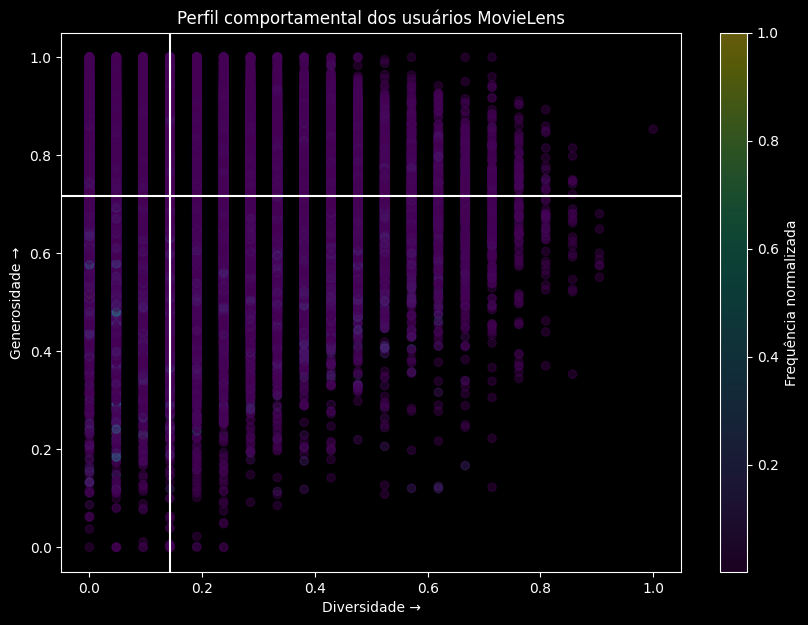

In [54]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,7))

scatter = ax.scatter(
    user_profile["diversidade_norm"],
    user_profile["generosidade_norm"],
    alpha=0.4,
    c=user_profile["frequencia_norm"],
    cmap="viridis"
)

ax.axvline(x_mediana)
ax.axhline(y_mediana)

ax.set_xlabel("Diversidade →")
ax.set_ylabel("Generosidade →")

ax.set_title(
    "Perfil comportamental dos usuários MovieLens"
)

fig.colorbar(
    scatter,
    ax=ax,
    label="Frequência normalizada"
)

plt.show()

C:\Users\jvict\AppData\Roaming\Python\Python314\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


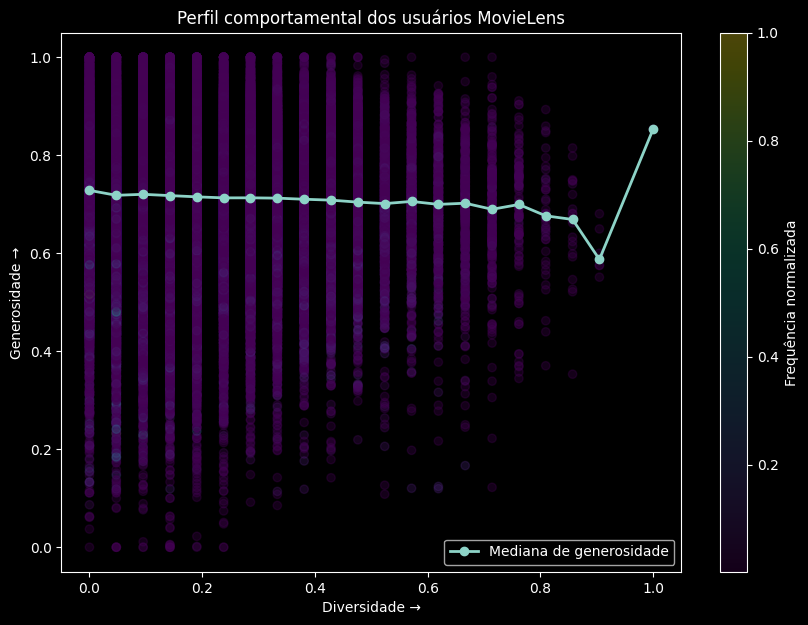

In [55]:
import matplotlib.pyplot as plt

# mediana de generosidade para cada diversidade
mediana_por_diversidade = (
    user_profile
    .groupby("diversidade_norm")["generosidade_norm"]
    .median()
)

fig, ax = plt.subplots(figsize=(10,7))

# pontos originais
scatter = ax.scatter(
    user_profile["diversidade_norm"],
    user_profile["generosidade_norm"],
    alpha=0.3,
    c=user_profile["frequencia_norm"],
    cmap="viridis"
)

# linha da mediana por diversidade
ax.plot(
    mediana_por_diversidade.index,
    mediana_por_diversidade.values,
    marker="o",
    linewidth=2,
    label="Mediana de generosidade"
)

ax.set_xlabel("Diversidade →")
ax.set_ylabel("Generosidade →")

ax.set_title(
    "Perfil comportamental dos usuários MovieLens"
)

ax.legend()

fig.colorbar(
    scatter,
    ax=ax,
    label="Frequência normalizada"
)

plt.show()

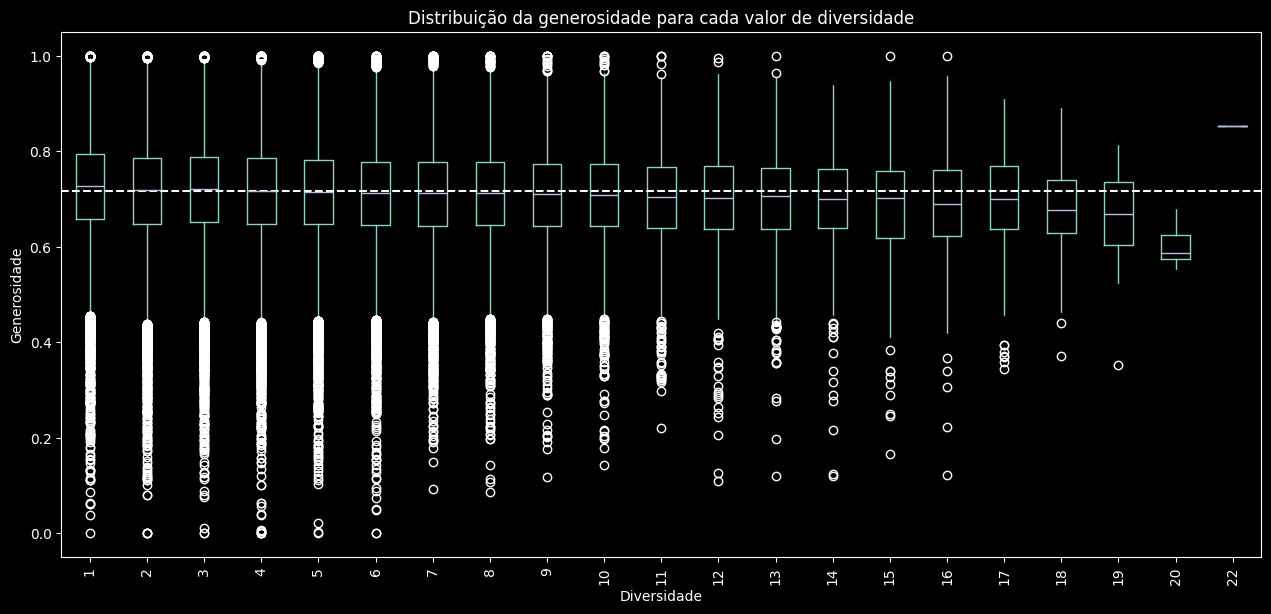

In [56]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,7))

user_profile.boxplot(
    column="generosidade_norm",
    by="num_clusters_preferidos",
    ax=ax,
    grid=False
)

ax.axhline(
    y_mediana,
    linestyle="--"
)

ax.set_xlabel("Diversidade")
ax.set_ylabel("Generosidade")

ax.set_title(
    "Distribuição da generosidade para cada valor de diversidade"
)

plt.suptitle("")
plt.xticks(rotation=90)

plt.show()

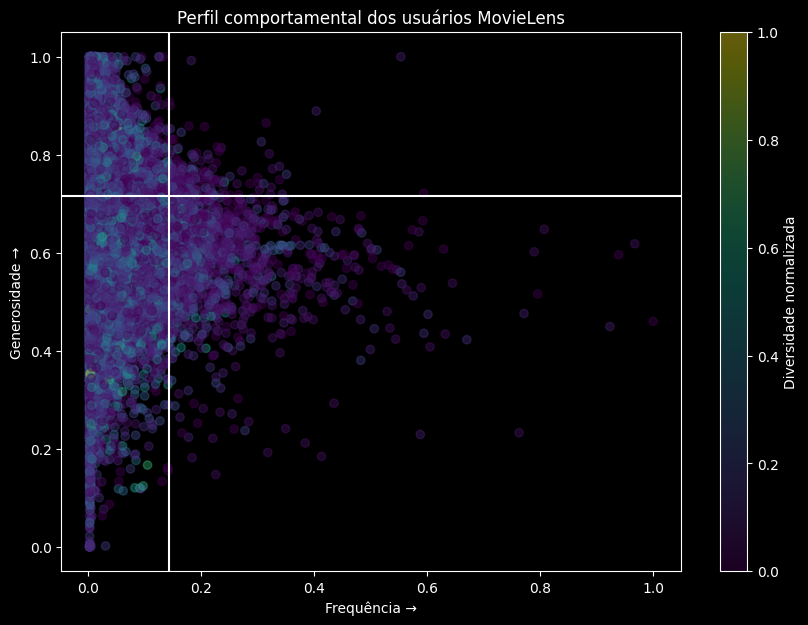

In [57]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10,7))

scatter = ax.scatter(
    user_profile["frequencia_norm"],
    user_profile["generosidade_norm"],
    alpha=0.4,
    c=user_profile["diversidade_norm"],
    cmap="viridis"
)

ax.axvline(x_mediana)
ax.axhline(y_mediana)

ax.set_xlabel("Frequência →")
ax.set_ylabel("Generosidade →")

ax.set_title(
    "Perfil comportamental dos usuários MovieLens"
)

# barra de cores
fig.colorbar(
    scatter,
    ax=ax,
    label="Diversidade normalizada"
)

plt.show()

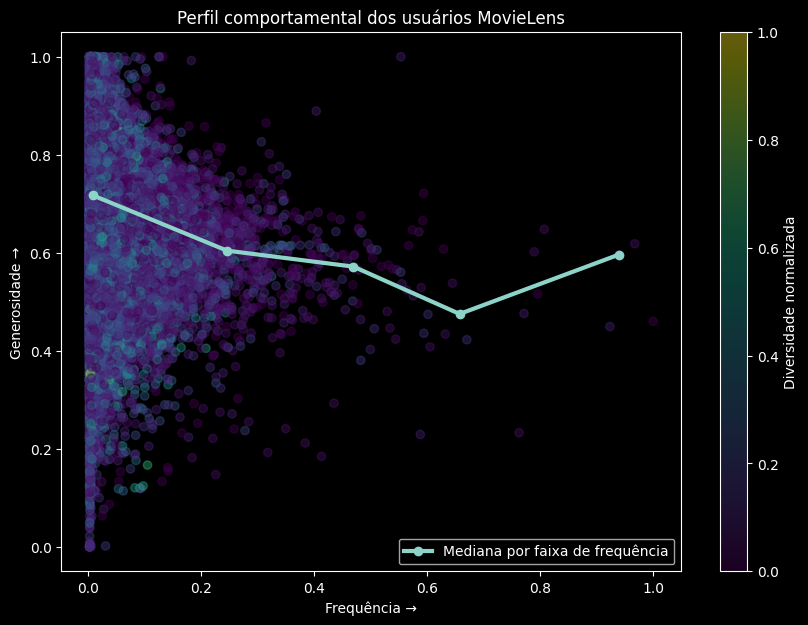

In [58]:
import matplotlib.pyplot as plt
import pandas as pd

# criar faixas de frequência
user_profile["frequencia_bin"] = pd.cut(
    user_profile["frequencia_norm"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0]
)

# calcular mediana em cada faixa
mediana_freq = (
    user_profile
    .groupby("frequencia_bin", observed=True)
    .agg({
        "frequencia_norm": "median",
        "generosidade_norm": "median"
    })
)

fig, ax = plt.subplots(figsize=(10,7))

scatter = ax.scatter(
    user_profile["frequencia_norm"],
    user_profile["generosidade_norm"],
    alpha=0.4,
    c=user_profile["diversidade_norm"],
    cmap="viridis"
)

# linha da mediana por faixa de frequência
ax.plot(
    mediana_freq["frequencia_norm"],
    mediana_freq["generosidade_norm"],
    marker="o",
    linewidth=3,
    label="Mediana por faixa de frequência"
)

ax.set_xlabel("Frequência →")
ax.set_ylabel("Generosidade →")

ax.set_title(
    "Perfil comportamental dos usuários MovieLens"
)

ax.legend()

fig.colorbar(
    scatter,
    ax=ax,
    label="Diversidade normalizada"
)

plt.show()

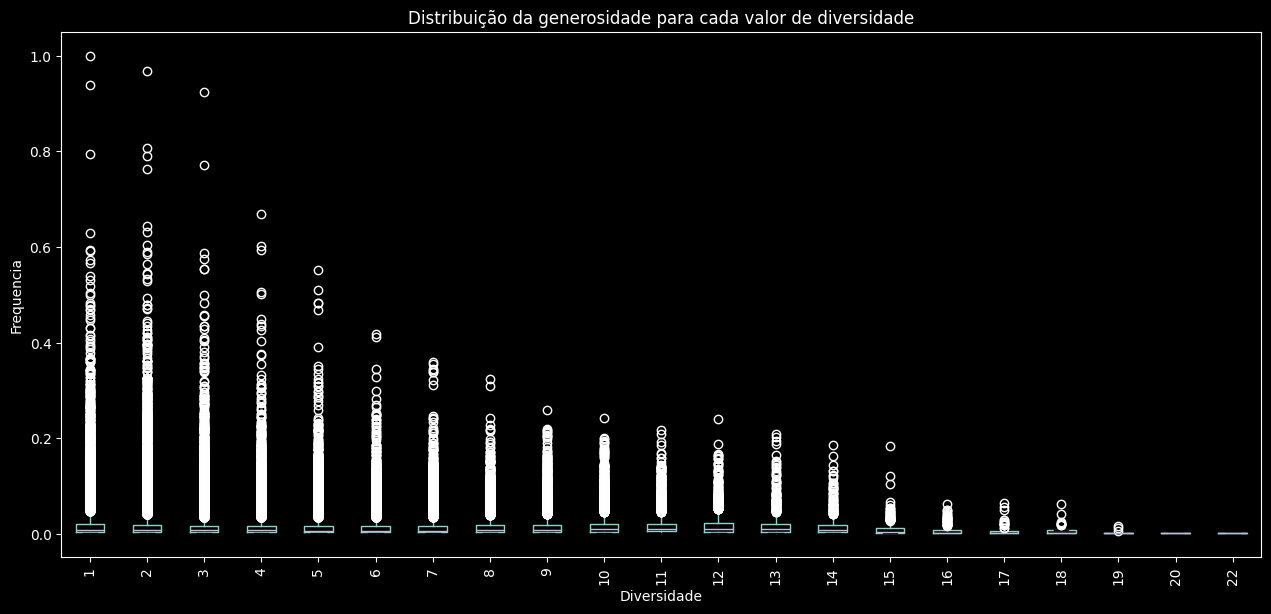

In [59]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(15,7))

user_profile.boxplot(
    column ="frequencia_norm",
    by="num_clusters_preferidos",
    ax=ax,
    grid=False
)


ax.set_xlabel("Diversidade")
ax.set_ylabel("Frequencia")

ax.set_title(
    "Distribuição da generosidade para cada valor de diversidade"
)

plt.suptitle("")
plt.xticks(rotation=90)

plt.show()

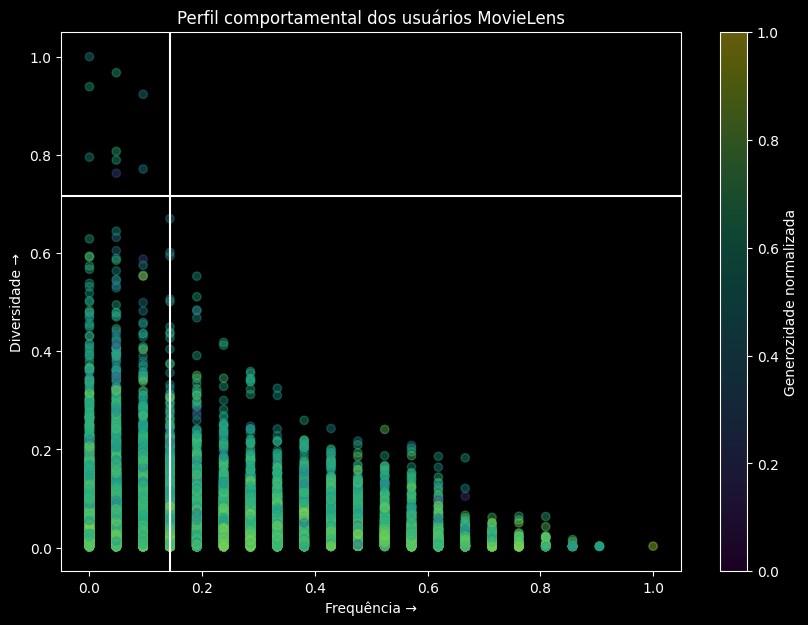

In [60]:
fig, ax = plt.subplots(figsize=(10,7))

scatter = ax.scatter(
    user_profile["diversidade_norm"],
    user_profile["frequencia_norm"],
    alpha=0.4,
    c=user_profile["generosidade_norm"],
    cmap="viridis"
)

ax.axvline(x_mediana)
ax.axhline(y_mediana)

ax.set_xlabel("Frequência →")
ax.set_ylabel("Diversidade →")

ax.set_title(
    "Perfil comportamental dos usuários MovieLens"
)

# barra de cores
fig.colorbar(
    scatter,
    ax=ax,
    label="Generozidade normalizada"
)

plt.show()

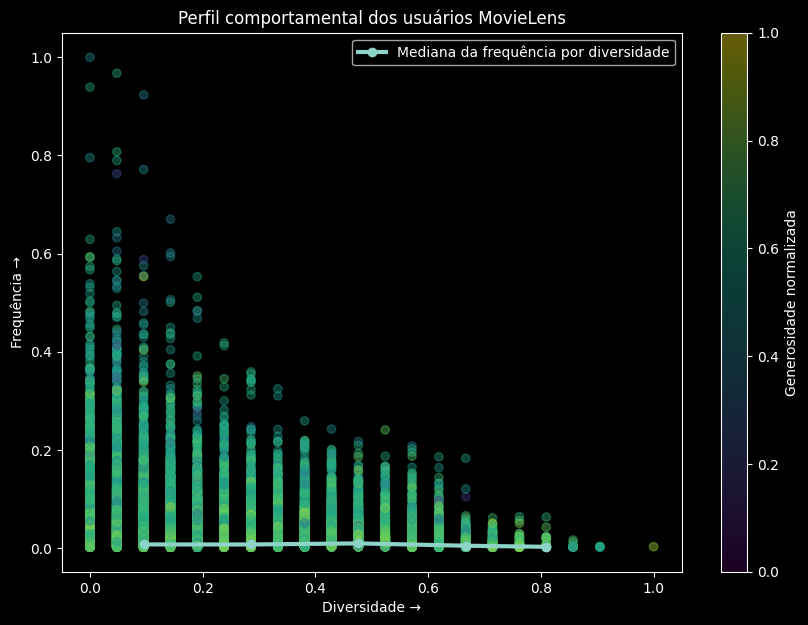

In [61]:
import matplotlib.pyplot as plt
import pandas as pd

# criar faixas de diversidade
user_profile["diversidade_bin"] = pd.cut(
    user_profile["diversidade_norm"],
    bins=[0, 0.2, 0.4, 0.6, 0.8, 1.0]
)

# mediana da frequência em cada faixa de diversidade
mediana_div = (
    user_profile
    .groupby("diversidade_bin", observed=True)
    .agg({
        "diversidade_norm": "median",
        "frequencia_norm": "median"
    })
)

fig, ax = plt.subplots(figsize=(10,7))

scatter = ax.scatter(
    user_profile["diversidade_norm"],
    user_profile["frequencia_norm"],
    alpha=0.4,
    c=user_profile["generosidade_norm"],
    cmap="viridis"
)

# linha da mediana da frequência por faixa de diversidade
ax.plot(
    mediana_div["diversidade_norm"],
    mediana_div["frequencia_norm"],
    marker="o",
    linewidth=3,
    label="Mediana da frequência por diversidade"
)

ax.set_xlabel("Diversidade →")
ax.set_ylabel("Frequência →")

ax.set_title(
    "Perfil comportamental dos usuários MovieLens"
)

ax.legend()

fig.colorbar(
    scatter,
    ax=ax,
    label="Generosidade normalizada"
)

plt.show()

In [62]:
# definir medianas

x_mediana = user_profile["diversidade_norm"].median()
y_mediana = user_profile["generosidade_norm"].median()
z_mediana = user_profile["frequencia_norm"].median()


def octante(row):

    # eixo X - diversidade
    if row["diversidade_norm"] >= x_mediana:
        x = "Eclético"
    else:
        x = "Focado"

    # eixo Y - generosidade
    if row["generosidade_norm"] >= y_mediana:
        y = "Generoso"
    else:
        y = "Crítico"

    # eixo Z - frequência
    if row["frequencia_norm"] >= z_mediana:
        z = "Frequente"
    else:
        z = "Casual"

    return x + "_" + y + "_" + z


user_profile["perfil_usuario"] = (
    user_profile.apply(octante, axis=1)
)

In [63]:
user_profile["perfil_usuario"].value_counts()

perfil_usuario
Eclético_Crítico_Frequente     32937
Eclético_Generoso_Casual       31519
Eclético_Crítico_Casual        28166
Eclético_Generoso_Frequente    26581
Focado_Generoso_Casual         23375
Focado_Crítico_Frequente       22846
Focado_Generoso_Frequente      19080
Focado_Crítico_Casual          16443
Name: count, dtype: int64

In [69]:
user_profile.head()


,userId,num_filmes,mean_rating,num_clusters,clusters_preferidos,num_clusters_preferidos,frequencia,diversidade,generosidade,frequencia_norm,diversidade_norm,generosidade_norm,perfil_usuario,frequencia_bin,diversidade_bin
0,1,141,3.531915,22,[1],1,141,0.033333,3.531915,0.014867,0.000000,0.673759,Focado_Crítico_Frequente,"(0.0, 0.2]",NaN
1,2,52,4.269231,17,"[0, 1, 4, 11, 15]",5,52,0.166667,4.269231,0.005483,0.190476,0.837607,Eclético_Generoso_Casual,"(0.0, 0.2]","(0.0, 0.2]"
2,3,147,3.588435,26,"[0, 1, 4, 7, 11, 20, 25]",7,147,0.233333,3.588435,0.015500,0.285714,0.686319,Eclético_Crítico_Frequente,"(0.0, 0.2]","(0.2, 0.4]"
3,4,27,2.629630,15,"[1, 4, 5, 6, 8, 9, 16, 27]",8,27,0.266667,2.629630,0.002847,0.333333,0.473251,Eclético_Crítico_Casual,"(0.0, 0.2]","(0.2, 0.4]"
4,5,33,3.272727,19,"[1, 4, 5, 9, 12, 18, 20, 25, 26]",9,33,0.300000,3.272727,0.003480,0.380952,0.616162,Eclético_Crítico_Casual,"(0.0, 0.2]","(0.2, 0.4]"


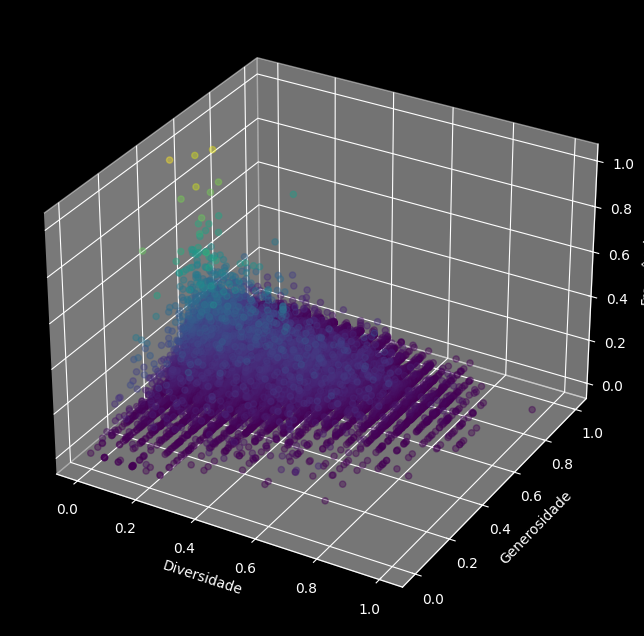

In [64]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    user_profile["diversidade_norm"],
    user_profile["generosidade_norm"],
    user_profile["frequencia_norm"],
    c=user_profile["frequencia_norm"],
    alpha=0.4
)

ax.set_xlabel("Diversidade")
ax.set_ylabel("Generosidade")
ax.set_zlabel("Frequência")

plt.show()

In [91]:
for user_id in user_profile["userId"]:

    perfil = user_profile.loc[
        user_profile["userId"] == user_id,
        "perfil_usuario"
    ].iloc[0]

    vistos = user_cluster_profile_all.loc[
        user_cluster_profile_all["userId"] == user_id,
        "movieId"
    ]

    recomendados = movie_ranking_top_10[
        ~movie_ranking_top_10["movieId"].isin(vistos)
    ]

    if perfil == "Focado_Crítico_Casual":

        recomendados = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        recomendados = (
            recomendados
            .sort_values("mean_rating", ascending=False)
            .head(10)
        )


    elif perfil == "Focado_Crítico_Frequente":

        recomendados = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        recomendados = (
            recomendados
            .sort_values("mean_rating", ascending=False)
            .head(20)
        )


    elif perfil == "Focado_Generoso_Casual":

        recomendados = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        recomendados = (
            recomendados
            .sort_values(
                ["cluster", "mean_rating"],
                ascending=[True, False]
            )
            .head(10)
        )


    elif perfil == "Focado_Generoso_Frequente":

        recomendados = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        recomendados = (
            recomendados
            .sort_values(
                ["cluster", "mean_rating"],
                ascending=[True, False]
            )
            .head(20)
        )


    elif perfil == "Eclético_Crítico_Casual":

        favoritos = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        outros = recomendados[
            ~recomendados["cluster"].isin(clusters)
        ]

        recomendados = pd.concat(
            [favoritos, outros]
        )

        recomendados = (
            recomendados
            .sort_values("mean_rating", ascending=False)
            .head(10)
        )


    elif perfil == "Eclético_Crítico_Frequente":

        favoritos = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        outros = recomendados[
            ~recomendados["cluster"].isin(clusters)
        ]

        recomendados = pd.concat(
            [favoritos, outros]
        )

        recomendados = (
            recomendados
            .sort_values("mean_rating", ascending=False)
            .head(20)
        )


    elif perfil == "Eclético_Generoso_Casual":

        recomendados = (
            recomendados
            .sort_values(
                ["cluster", "mean_rating"],
                ascending=[True, False]
            )
            .head(10)
        )


    elif perfil == "Eclético_Generoso_Frequente":

        recomendados = (
            recomendados
            .sort_values(
                ["cluster", "mean_rating"],
                ascending=[True, False]
            )
            .head(20)
        )

KeyboardInterrupt: 


KeyboardInterrupt



In [93]:
for user_id in user_profile["userId"].head(5):

    perfil = user_profile.loc[
        user_profile["userId"] == user_id,
        "perfil_usuario"
    ].iloc[0]

    vistos = user_cluster_profile_all.loc[
        user_cluster_profile_all["userId"] == user_id,
        "movieId"
    ]

    recomendados = movie_ranking_top_10[
        ~movie_ranking_top_10["movieId"].isin(vistos)
    ]

    if perfil == "Focado_Crítico_Casual":

        recomendados = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        recomendados = (
            recomendados
            .sort_values("mean_rating", ascending=False)
            .head(10)
        )


    elif perfil == "Focado_Crítico_Frequente":

        recomendados = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        recomendados = (
            recomendados
            .sort_values("mean_rating", ascending=False)
            .head(20)
        )


    elif perfil == "Focado_Generoso_Casual":

        recomendados = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        recomendados = (
            recomendados
            .sort_values(
                ["cluster", "mean_rating"],
                ascending=[True, False]
            )
            .head(10)
        )


    elif perfil == "Focado_Generoso_Frequente":

        recomendados = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        recomendados = (
            recomendados
            .sort_values(
                ["cluster", "mean_rating"],
                ascending=[True, False]
            )
            .head(20)
        )


    elif perfil == "Eclético_Crítico_Casual":

        favoritos = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        outros = recomendados[
            ~recomendados["cluster"].isin(clusters)
        ]

        recomendados = pd.concat(
            [favoritos, outros]
        )

        recomendados = (
            recomendados
            .sort_values("mean_rating", ascending=False)
            .head(10)
        )


    elif perfil == "Eclético_Crítico_Frequente":

        favoritos = recomendados[
            recomendados["cluster"].isin(clusters)
        ]

        outros = recomendados[
            ~recomendados["cluster"].isin(clusters)
        ]

        recomendados = pd.concat(
            [favoritos, outros]
        )

        recomendados = (
            recomendados
            .sort_values("mean_rating", ascending=False)
            .head(20)
        )


    elif perfil == "Eclético_Generoso_Casual":

        recomendados = (
            recomendados
            .sort_values(
                ["cluster", "mean_rating"],
                ascending=[True, False]
            )
            .head(10)
        )


    elif perfil == "Eclético_Generoso_Frequente":

        recomendados = (
            recomendados
            .sort_values(
                ["cluster", "mean_rating"],
                ascending=[True, False]
            )
            .head(20)
        )

    # print pra você ver o resultado (o código original não tinha isso)
    print(f"\n=== Usuário {user_id} | Perfil: {perfil} ===")
    print(recomendados[["movieId", "cluster", "mean_rating"]])


=== Usuário 1 | Perfil: Focado_Crítico_Frequente ===
     movieId  cluster  mean_rating
30    171011        3     4.445150
31    159817        3     4.443653
140   170705       14     4.433923
130      318       13     4.396570
32    179135        3     4.318269
131      858       13     4.310549
100   202439       10     4.309610
10    198185        1     4.285252
11    220528        1     4.283845
70    163809        7     4.263088
33    105250        3     4.254958
210       50       21     4.251212
34    142115        3     4.247041
141     2019       14     4.234044
50      2959        5     4.229128
14     26082        1     4.211189
71      5618        7     4.210689
120      904       12     4.207438
250   286897       25     4.207006
51       296        5     4.201195

=== Usuário 2 | Perfil: Eclético_Generoso_Casual ===
   movieId  cluster  mean_rating
0      905        0     4.085007
1    98491        0     4.078450
2   127052        0     4.075548
3     4973        0     4